
=== Logistic Regression ===
Accuracy  : 0.9625
Precision : 0.9143
Recall    : 1.0000
F1 Score  : 0.9552


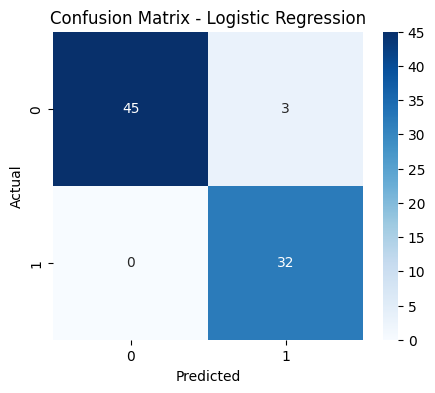


=== Random Forest ===
Accuracy  : 0.9375
Precision : 0.9091
Recall    : 0.9375
F1 Score  : 0.9231


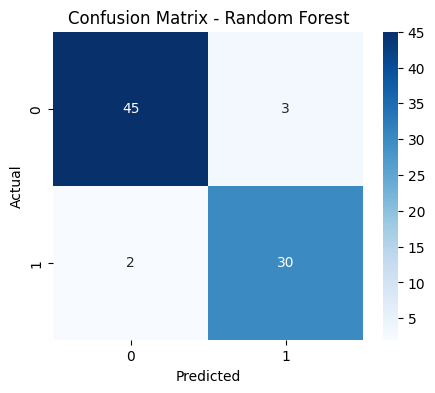


Final model used: Logistic Regression

predictions.csv created successfully!
Prediction distribution: {0: np.float64(0.61), 1: np.float64(0.39)}


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

train = pd.read_csv('ml_dataset_v1_train.csv')
dev   = pd.read_csv('ml_dataset_v1_dev.csv')
test  = pd.read_csv('ml_dataset_v1_public_test.csv')

def add_features(df):
    df = df.copy()
    df['gpa_attendance'] = df['gpa'] * df['attendance_rate']
    df['study_exam'] = df['study_hours_per_week'] * df['exam_score']
    df['income_per_study'] = df['household_income'] / (df['study_hours_per_week'] + 1)
    return df

train = add_features(train)
dev   = add_features(dev)
test  = add_features(test)

X_train = train.drop(['id', 'label'], axis=1)
y_train = train['label']
X_dev = dev.drop(['id', 'label'], axis=1)
y_dev = dev['label']
X_test = test.drop(['id'], axis=1)
if 'label' in X_test.columns:
    X_test = X_test.drop(['label'], axis=1)
test_ids = test['id']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_dev_scaled   = scaler.transform(X_dev)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000, random_state=42, solver='liblinear')
grid_lr = GridSearchCV(lr, {'C': [0.1, 1, 10, 50]}, cv=5, scoring='f1', n_jobs=1)
grid_lr.fit(X_train_scaled, y_train)
best_lr = grid_lr.best_estimator_

rf = RandomForestClassifier(random_state=42, n_jobs=1)
grid_rf = GridSearchCV(rf, {
    'n_estimators': [200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5]
}, cv=5, scoring='f1', n_jobs=1)
grid_rf.fit(X_train_scaled, y_train)
best_rf = grid_rf.best_estimator_

def evaluate_model(model, X, y, name):
    pred = model.predict(X)
    print(f"\n=== {name} ===")
    print(f"Accuracy  : {accuracy_score(y, pred):.4f}")
    print(f"Precision : {precision_score(y, pred):.4f}")
    print(f"Recall    : {recall_score(y, pred):.4f}")
    print(f"F1 Score  : {f1_score(y, pred):.4f}")
    
    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

evaluate_model(best_lr, X_dev_scaled, y_dev, "Logistic Regression")
evaluate_model(best_rf, X_dev_scaled, y_dev, "Random Forest")

final_model = best_lr  
print("\nFinal model used: Logistic Regression")

y_test_pred = final_model.predict(X_test_scaled)

submission = pd.DataFrame({
    'id': test_ids,
    'label_pred': y_test_pred
})

submission.to_csv('predictions.csv', index=False)

print("\npredictions.csv created successfully!")
print("Prediction distribution:", dict(submission['label_pred'].value_counts(normalize=True)))